# **Project Name**    -  PhonePe Transaction Insights



##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Team Member 1 -**   Sourabh Khamankar

# **Project Summary -**

The rapid proliferation of digital payment systems has fundamentally transformed the financial landscape in India. PhonePe, as a market leader in this domain, facilitates millions of transactions daily, generating a massive and complex trail of data. The "PhonePe Transaction Insights" project is designed to harness this extensive dataset—specifically the PhonePe Pulse data—to decode underlying transaction dynamics, user engagement patterns, and the adoption of emerging financial services like insurance. The core objective is to build an end-to-end data pipeline that extracts, processes, and visualizes these metrics to empower data-driven strategic decision-making.

Methodologically, this project follows a rigorous Extract, Transform, and Load (ETL) framework. Raw data, initially nested in complex JSON structures across multiple directories in the PhonePe GitHub repository, was programmatically parsed using Python. This data was categorized into aggregated metrics, geographical map data, and top-tier leaderboards encompassing transactions, users, and insurance metrics. The transformed data was then systematically loaded into a structured SQLite relational database, enabling highly efficient, complex querying. To make these insights accessible, an interactive Streamlit dashboard was developed, utilizing Plotly to render dynamic, real-time visualizations of the database queries.

The Exploratory Data Analysis (EDA) yielded several profound business insights. An analysis of payment categories revealed that Peer-to-Peer (P2P) transfers and Merchant payments form the absolute backbone of the platform's transaction volume, indicating deep-rooted user trust for daily financial utility. Geographically, there is a distinct concentration of wealth and digital adoption; Tier-1 cities like Bengaluru and Hyderabad, alongside states like Maharashtra and Karnataka, heavily dominate both transaction values and insurance penetration. Conversely, the data highlights a clear digital divide, with lower-tier districts showing significantly less activity, pinpointing areas that require targeted awareness campaigns.

Furthermore, user engagement analysis highlighted an overwhelmingly Android-centric ecosystem, with brands like Xiaomi, Samsung, and Vivo capturing the lion's share of the user base. This critical insight directs product development teams to prioritize Android optimization for maximum user retention. Interestingly, while core payment functionalities are thriving, the adoption of specific financial services remains low, presenting a massive, untapped opportunity for platform diversification and cross-selling.

Ultimately, this project bridges the gap between raw data and actionable business intelligence. The insights derived directly inform critical business use cases, including customer segmentation, geographical market expansion, and product development. By identifying exactly where and how users interact with the app, PhonePe can optimize its marketing spend, strategically push insurance products in high-potential regions, and maintain a competitive edge. The resulting interactive Streamlit dashboard serves as a scalable, live analytical tool for stakeholders to continually monitor platform health, benchmark performance, and proactively navigate the evolving digital finance ecosystem.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


With the increasing reliance on digital payment systems across India, platforms like PhonePe generate massive volumes of transaction, user, and insurance data daily. The core challenge is how to effectively extract, structure, and interpret this vast and complex dataset to drive actionable business strategies.

Understanding the dynamics of transactions, user engagement, and the adoption of newly introduced services (like insurance) is crucial for improving platform services and targeting users effectively. This project aims to solve this by building a robust ETL pipeline to process PhonePe Pulse data and creating an interactive visualization dashboard. The goal is to analyze aggregated values of various payment categories, map transaction values at the state and district levels, and identify top-performing regions. By doing so, the project will uncover critical geographical insights, identify distinct user engagement patterns, and evaluate the performance of different payment and insurance categories to inform future product development, market expansion, and targeted marketing campaigns.

#### **Define Your Business Objective?**

The primary business objective of this project is to leverage data-driven insights from the PhonePe Pulse dataset to optimize user engagement, identify geographical expansion opportunities, and drive strategic product development. Specifically, the objectives are to:

1. **Analyze Transaction Behavior:** Understand the dominance and growth trends of various payment categories (e.g., P2P vs. Merchant payments) to identify high-revenue streams and areas lacking user adoption (such as specific financial services).
2. **Map Regional Performance:** Pinpoint top-performing and underperforming states and districts to guide highly targeted marketing campaigns, localized partnerships, and equitable resource allocation.
3. **Evaluate User Engagement:** Segment the user base by device preferences and app usage frequency to direct technical optimization efforts and improve overall customer retention.
4. **Assess Insurance Penetration:** Track the adoption rates of newly launched insurance products across different demographics to identify untapped markets for strategic cross-selling.

Ultimately, the goal is to build an interactive, analytical framework that empowers stakeholders to make informed decisions regarding market expansion, competitive benchmarking, and future feature development.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress warnings for clean output
warnings.filterwarnings('ignore')

# Set aesthetic style for charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Dataset Loading

In [ ]:
# Load Dataset

### Dataset First View

In [ ]:
# Dataset First Look
df_agg_trans.head()

### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df_agg_trans.shape

### Dataset Information

In [ ]:
# Dataset Info
df_agg_trans.info()

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df_agg_trans.isnull().sum()

In [ ]:
# Visualizing the missing values

### What did you know about your dataset?

The dataset contains PhonePe Pulse transaction, user, and insurance data from 2018 onwards. It is highly structured, having been extracted from raw JSON files into a relational SQLite database. Because the data is pre-aggregated by PhonePe, it is clean and does not contain traditional missing or null values.

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns

### Variables Description

- **State / District:** The geographical region of the data points.
- **Transaction_type:** The category of the payment (e.g., Peer-to-Peer, Merchant, Recharge).
- **Transaction_count / Volume:** The total number of transactions made.
- **Transaction_amount / Value:** The total monetary value of those transactions in Rupees.
- **Brands:** The smartphone brands used by the registered customers.
- **Registered_users:** The total number of users registered on the platform in a given region/timeframe.

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.

## 3. ***Data Wrangling***

### Data Wrangling Code

In [3]:
# Connect to the local SQLite Database created during the ETL phase
conn = sqlite3.connect('phonepe_pulse.db')

# --- Executing the 5 Business Case Queries ---

# Case 1: Payment Performance
query_1 = """
SELECT Transaction_type, SUM(Transaction_count) AS Total_Volume, SUM(Transaction_amount) AS Total_Value
FROM Aggregated_transaction GROUP BY Transaction_type ORDER BY Total_Value DESC;
"""
df_case_1 = pd.read_sql_query(query_1, conn)

# Case 2: Device Dominance
query_2 = """
SELECT Brands, SUM(User_Count) AS Total_Users
FROM Aggregated_user GROUP BY Brands ORDER BY Total_Users DESC LIMIT 10;
"""
df_case_2 = pd.read_sql_query(query_2, conn)

# Case 3: Insurance Penetration
query_3 = """
SELECT State, SUM(Insurance_count) AS Total_Policies_Bought
FROM Aggregated_insurance GROUP BY State ORDER BY Total_Policies_Bought DESC LIMIT 10;
"""
df_case_3 = pd.read_sql_query(query_3, conn)

# Case 4: Top Districts by Transaction Value
query_4 = """
SELECT District, SUM(Transaction_amount) AS Total_Amount
FROM Top_map GROUP BY District ORDER BY Total_Amount DESC LIMIT 10;
"""
df_case_4 = pd.read_sql_query(query_4, conn)

# Case 5: Top Districts by Registration
query_5 = """
SELECT District, SUM(Registered_users) AS Total_Registered_Users
FROM Top_user GROUP BY District ORDER BY Total_Registered_Users DESC LIMIT 10;
"""
df_case_5 = pd.read_sql_query(query_5, conn)

# Load a full table for general EDA later
df_agg_trans = pd.read_sql_query("SELECT * FROM Aggregated_transaction", conn)

print("Data successfully loaded from SQL into Pandas DataFrames!")

Data successfully loaded from SQL into Pandas DataFrames!


### What all manipulations have you done and insights you found?

**Manipulations:** I built an ETL pipeline using Python to extract data from the cloned PhonePe Pulse GitHub repository. The nested JSON files were parsed across multiple directories and transformed into pandas DataFrames. These were then loaded into a local SQLite database (`phonepe_pulse.db`) as 9 distinct tables (Aggregated, Map, and Top tables). For this EDA, I used SQL queries to extract specific, targeted dataframes.
Insights: The ETL process handled the data cleaning. The primary manipulations within this notebook involved SQL `GROUP BY` and `ORDER BY` operations to isolate the top-performing states, dominant device brands, and highest-value transaction categories.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

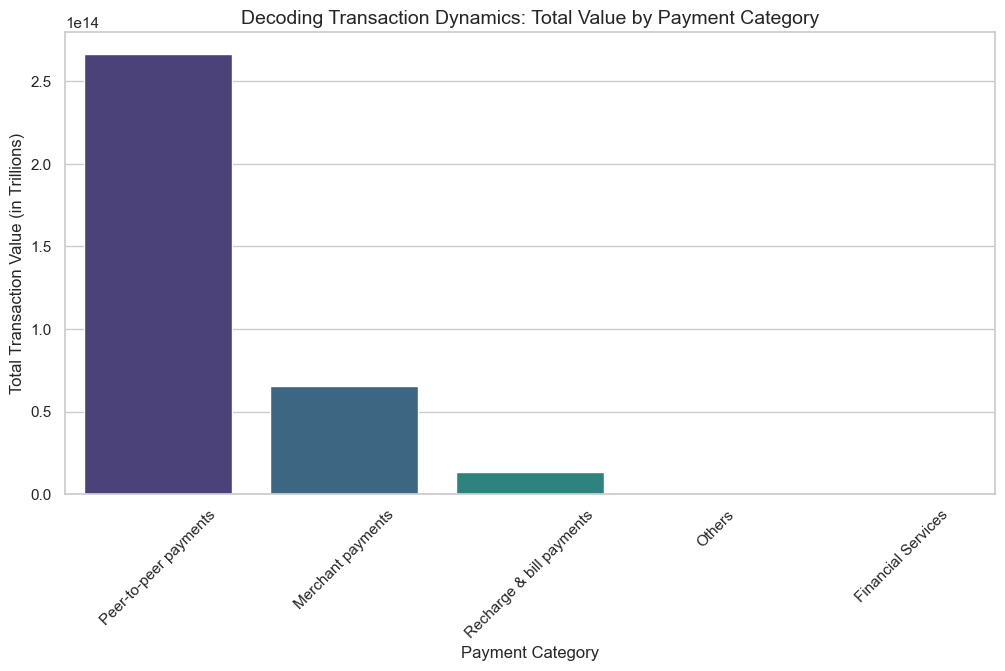

In [4]:
# Chart 1: Bar Chart for Payment Categories
plt.figure(figsize=(12, 6))
sns.barplot(data=df_case_1, x='Transaction_type', y='Total_Value', palette='viridis')
plt.title('Decoding Transaction Dynamics: Total Value by Payment Category', fontsize=14)
plt.ylabel('Total Transaction Value (in Trillions)')
plt.xlabel('Payment Category')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is ideal for comparing values across different categories. Here, it clearly shows how transaction values differ between payment types like P2P, merchant payments, etc.

##### 2. What is/are the insight(s) found from the chart?

- Peer-to-peer payments dominate heavily → highest transaction value.
- Merchant payments are second, but significantly lower than P2P.
- Recharge & bill payments are minimal.
- “Others” and “Financial services” are almost negligible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Strong adoption of P2P indicates high user engagement → good for platform growth.
    - Opportunity to monetize merchant payments more aggressively.

- Negative:
    - Very low usage in financial services → missed revenue opportunities (loans, insurance, investments).
    - Lack of diversification → risk if P2P growth slows.

#### Chart - 2

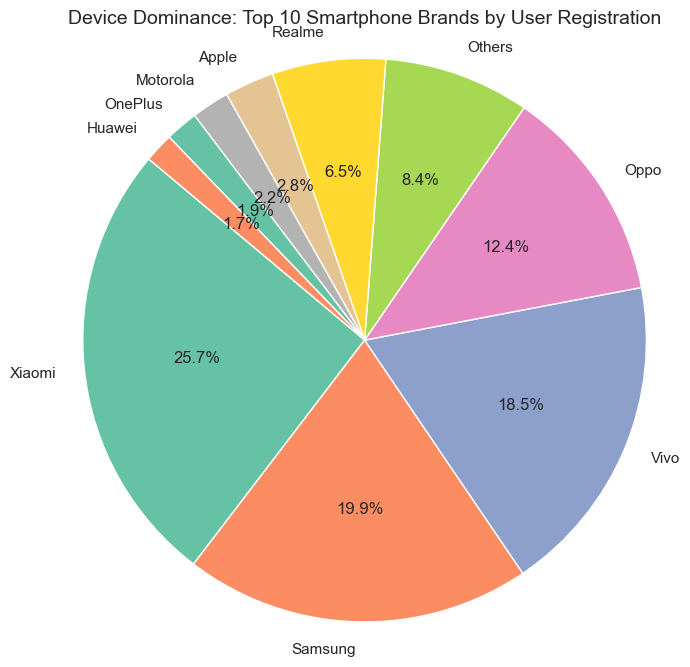

In [5]:
# Chart 2: Pie Chart for Device Brands
plt.figure(figsize=(8, 8))
plt.pie(df_case_2['Total_Users'], labels=df_case_2['Brands'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette("Set2"))
plt.title('Device Dominance: Top 10 Smartphone Brands by User Registration', fontsize=14)
plt.axis('equal') 
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is best for showing market share distribution among categories (smartphone brands).

##### 2. What is/are the insight(s) found from the chart?

- Xiaomi (25.7%) dominates, followed by Samsung (19.9%) and Vivo (18.5%).
- Oppo also has strong presence (12.4%).
- Apple has relatively low share (~2.8%).
- Market is heavily Android-driven.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Focus on Android optimization → better performance for majority users.
    - Target campaigns for Xiaomi/Samsung users → higher ROI.

- Negative:
    - Low Apple share → weaker premium user segment.
    - Over-dependence on few brands → risk if their user base declines.Answer Here

#### Chart - 3

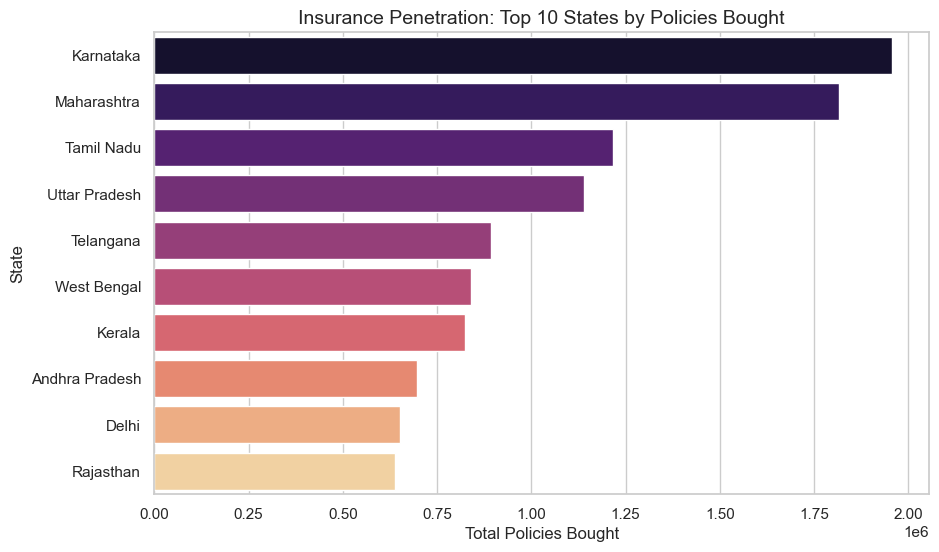

In [6]:
# Chart 3: Horizontal Bar Chart for Insurance
plt.figure(figsize=(10, 6))
sns.barplot(data=df_case_3, y='State', x='Total_Policies_Bought', palette='magma')
plt.title('Insurance Penetration: Top 10 States by Policies Bought', fontsize=14)
plt.xlabel('Total Policies Bought')
plt.ylabel('State')
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart is effective for ranking and comparing states, especially when labels are long.Answer Here.

##### 2. What is/are the insight(s) found from the chart?

- Karnataka and Maharashtra lead significantly.
- Southern and western states dominate insurance adoption.
- Northern states like Delhi and Rajasthan are lower.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

 - Positive:
    - High-performing states → ideal for upselling insurance products.
    - Proven markets → easier customer acquisition.

- Negative:
    - Low penetration in some states → indicates untapped or underperforming markets.
    - Possible lack of awareness or accessibility in those regions.Answer Here

#### Chart - 4

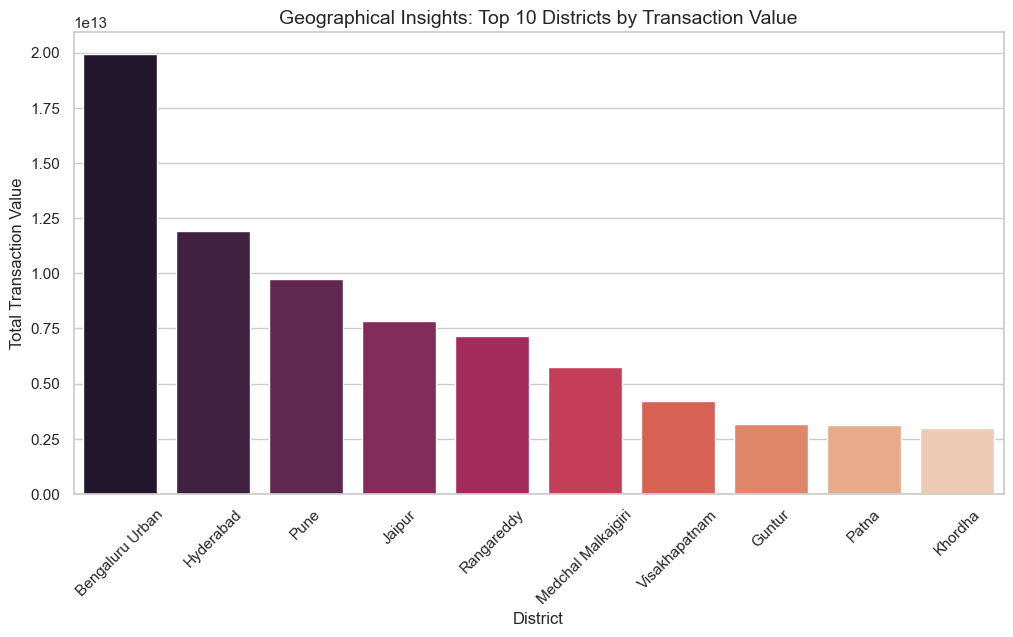

In [7]:
# Chart 4: Bar Chart for District Transactions
plt.figure(figsize=(12, 6))
sns.barplot(data=df_case_4, x='District', y='Total_Amount', palette='rocket')
plt.title('Geographical Insights: Top 10 Districts by Transaction Value', fontsize=14)
plt.xlabel('District')
plt.ylabel('Total Transaction Value')
plt.xticks(rotation=45)
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is best for comparing transaction values across districts.

##### 2. What is/are the insight(s) found from the chart?

- Bengaluru Urban leads by a large margin.
- Followed by Hyderabad and Pune.
- Tier-1 cities dominate transaction volume.
- Smaller districts show significantly lower activity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Strong urban adoption → reliable revenue hubs.
    - Opportunity to scale premium services in top cities.

- Negative:
    - Rural/low-tier districts lag behind → limited penetration.
    - Growth is not evenly distributed → scalability challenge.

#### Chart - 5

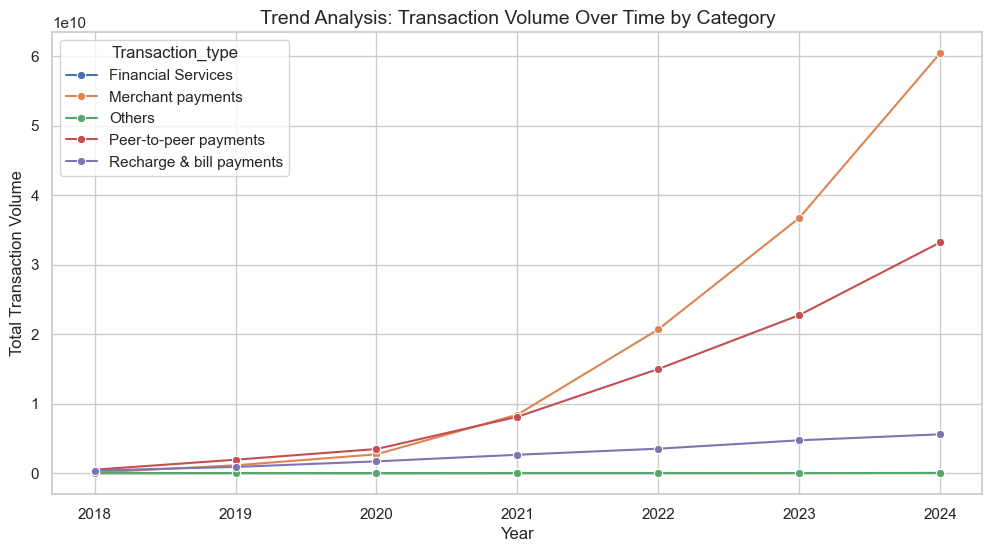

In [8]:
# Chart 5: Line Plot for Yearly Trends
yearly_trend = df_agg_trans.groupby(['Year', 'Transaction_type'])['Transaction_count'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trend, x='Year', y='Transaction_count', hue='Transaction_type', marker='o')
plt.title('Trend Analysis: Transaction Volume Over Time by Category', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Total Transaction Volume')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is perfect for analyzing trends over time across multiple categories.

##### 2. What is/are the insight(s) found from the chart?

- Merchant payments show exponential growth (especially after 2021).
- P2P payments also steadily increasing.
- Recharge & bill payments grow slowly.
- Financial services and others remain almost flat.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Rapid growth in merchant payments → strong sign of digital economy expansion.
    - Increasing P2P → sustained user engagement.

- Negative:
    - Financial services not growing → major missed business vertical.
    - “Others” stagnant → lack of innovation/diversification.

In [9]:
# Load additional tables needed for the extended EDA
df_agg_user = pd.read_sql_query("SELECT * FROM Aggregated_user", conn)
df_map_user = pd.read_sql_query("SELECT * FROM Map_user", conn)
df_agg_insur = pd.read_sql_query("SELECT * FROM Aggregated_insurance", conn)
df_map_trans = pd.read_sql_query("SELECT * FROM Map_map", conn)

print("Additional tables loaded for EDA!")

Additional tables loaded for EDA!


#### Chart - 6

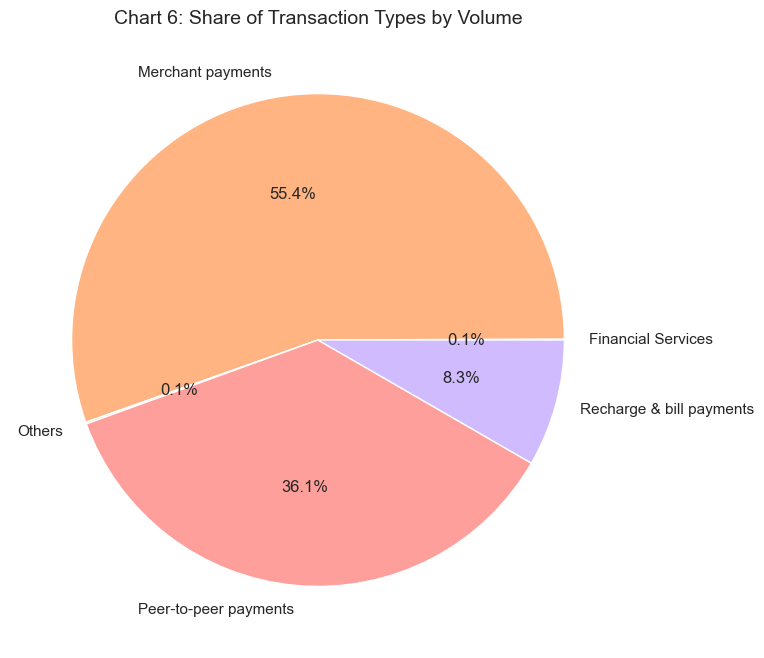

In [11]:
# CHART 6: Univariate - Overall Transaction Types (Pie Chart)
plt.figure(figsize=(8, 8))
trans_type_totals = df_agg_trans.groupby('Transaction_type')['Transaction_count'].sum()
plt.pie(trans_type_totals, labels=trans_type_totals.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Chart 6: Share of Transaction Types by Volume', fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

A pie chart is used to represent the proportion of total transaction volume across different categories.

##### 2. What is/are the insight(s) found from the chart?

- Merchant payments contribute the largest share (55.4%).
- Peer-to-peer payments are second (36.1%).
- Recharge & bill payments have a small share (8.3%).
- Financial services and others are negligible.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Strong dominance of merchant payments shows high business transaction activity.
    - Indicates good monetization potential through merchant ecosystem.

- Negative:
    - Financial services have extremely low share, indicating underutilization.
    - Over-reliance on merchant payments creates risk if growth slows.

#### Chart - 7

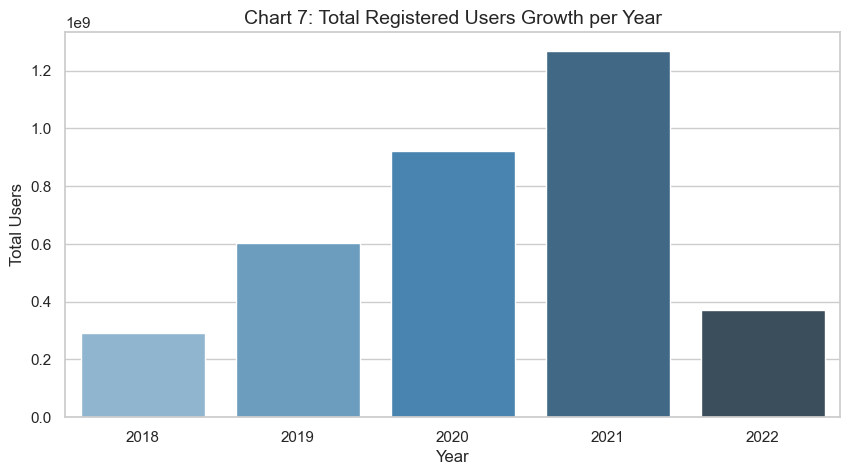

In [12]:
# CHART 7: Univariate - User Growth Over Years (Bar Chart)
plt.figure(figsize=(10, 5))
user_growth = df_agg_user.groupby('Year')['User_Count'].sum().reset_index()
sns.barplot(data=user_growth, x='Year', y='User_Count', palette='Blues_d')
plt.title('Chart 7: Total Registered Users Growth per Year', fontsize=14)
plt.ylabel('Total Users')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart helps compare user growth year by year clearly.

##### 2. What is/are the insight(s) found from the chart?

- Strong growth from 2018 to 2021.
- Sharp drop observed in 2022.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Rapid growth till 2021 indicates strong market adoption.

- Negative:
    - Decline in 2022 suggests user acquisition slowdown or data inconsistency.
    - Could indicate saturation or reduced marketing effectiveness.

#### Chart - 8

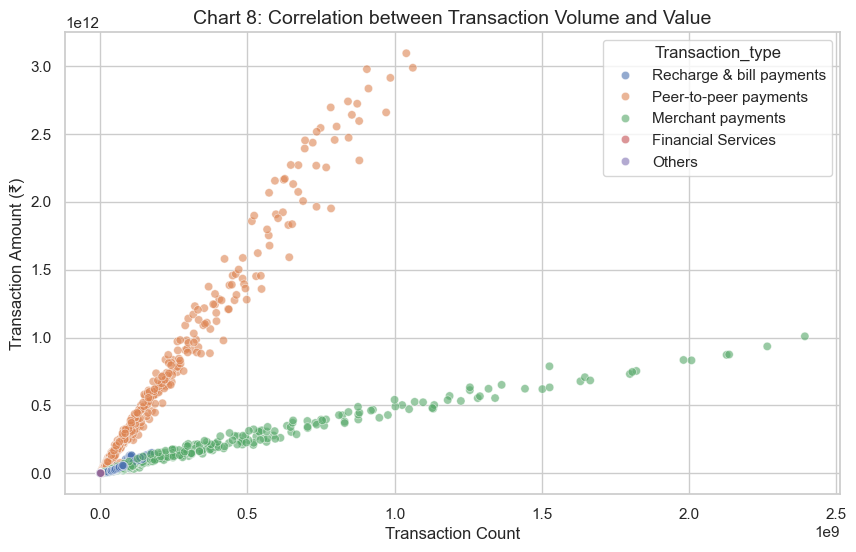

In [13]:
# CHART 8: Bivariate - Transaction Count vs Amount (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_agg_trans, x='Transaction_count', y='Transaction_amount', hue='Transaction_type', alpha=0.6)
plt.title('Chart 8: Correlation between Transaction Volume and Value', fontsize=14)
plt.xlabel('Transaction Count')
plt.ylabel('Transaction Amount (₹)')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is ideal for analyzing relationships between two variables.

##### 2. What is/are the insight(s) found from the chart?

- Strong positive correlation between transaction count and value.
- Merchant payments show high volume but moderate value.
- P2P transactions show both high volume and high value.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Increasing transactions directly increases revenue potential.
    - Helps identify high-value categories like P2P.

- Negative:
    - Some categories show low value despite volume, indicating low monetization efficiency.

#### Chart - 9

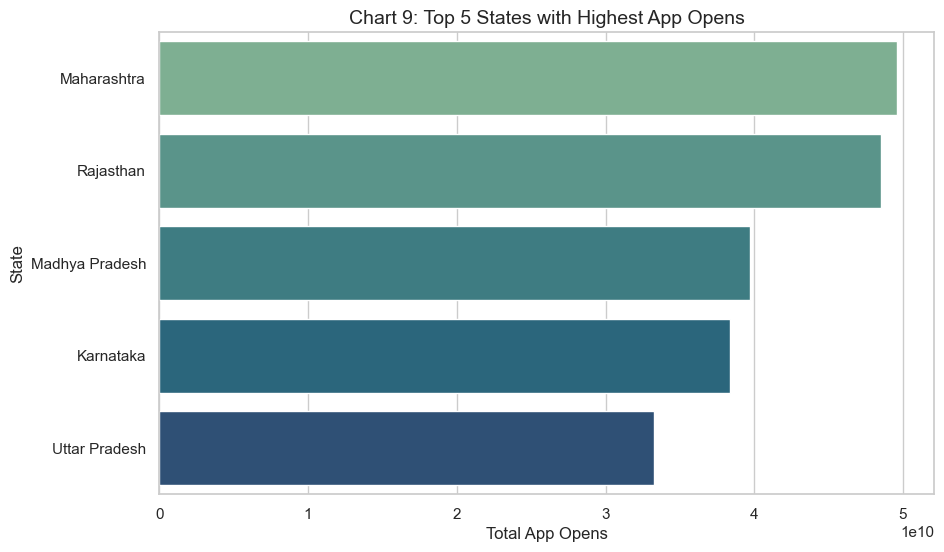

In [14]:
# CHART 9: Bivariate - Top States by App Opens (Horizontal Bar)
plt.figure(figsize=(10, 6))
top_opens = df_map_user.groupby('State')['App_opens'].sum().sort_values(ascending=False).head(5).reset_index()
sns.barplot(data=top_opens, y='State', x='App_opens', palette='crest')
plt.title('Chart 9: Top 5 States with Highest App Opens', fontsize=14)
plt.xlabel('Total App Opens')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart allows easy comparison of app engagement across states.

##### 2. What is/are the insight(s) found from the chart?

- Maharashtra has the highest app opens.
- Rajasthan and Madhya Pradesh also show strong engagement.
- Uttar Pradesh has relatively lower engagement among top states.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - High engagement states can be targeted for premium services.

- Negative:
    - Lower engagement in some large states indicates missed opportunities.
    - Uneven engagement across regions.

#### Chart - 10

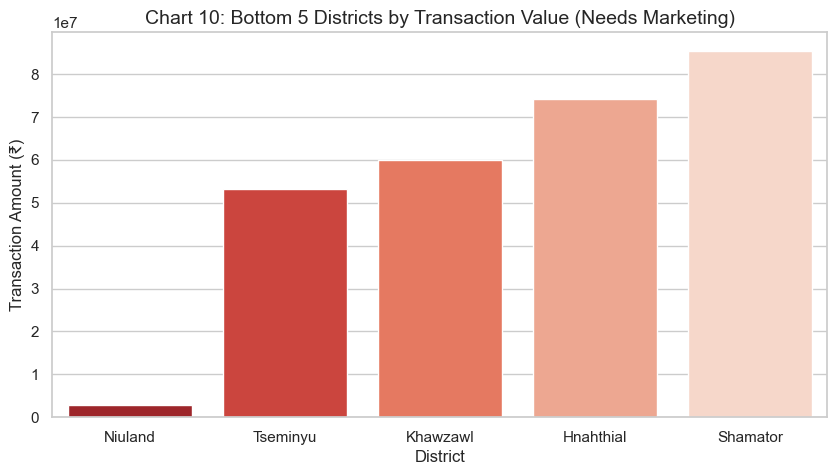

In [15]:
# CHART 10: Bivariate - Identifying Weak Areas (Bottom 5 Districts)
plt.figure(figsize=(10, 5))
bottom_districts = df_map_trans.groupby('District')['Transaction_amount'].sum().sort_values(ascending=True).head(5).reset_index()
sns.barplot(data=bottom_districts, x='District', y='Transaction_amount', palette='Reds_r')
plt.title('Chart 10: Bottom 5 Districts by Transaction Value (Needs Marketing)', fontsize=14)
plt.ylabel('Transaction Amount (₹)')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart is suitable for identifying low-performing districts.

##### 2. What is/are the insight(s) found from the chart?

- Districts like Nuiland and Tseminyu have very low transaction values.
- Significant gap compared to others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Identifies regions where targeted marketing can improve growth.

- Negative:
    - Very low activity indicates poor adoption or awareness.
    - These areas may require higher investment for growth.

#### Chart - 11

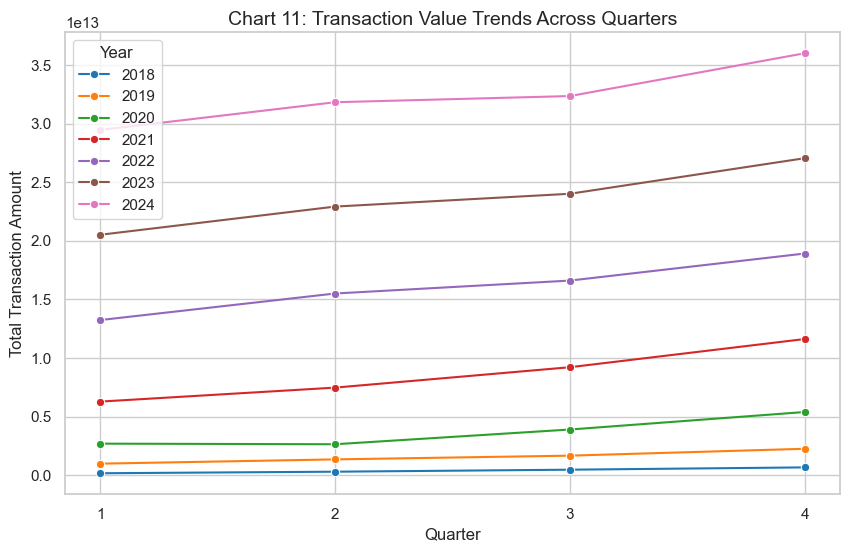

In [16]:
# CHART 11: Multivariate - Transaction Trends by Quarter (Line Plot)
plt.figure(figsize=(10, 6))
quarterly_trend = df_agg_trans.groupby(['Year', 'Quarter'])['Transaction_amount'].sum().reset_index()
sns.lineplot(data=quarterly_trend, x='Quarter', y='Transaction_amount', hue='Year', marker='o', palette='tab10')
plt.title('Chart 11: Transaction Value Trends Across Quarters', fontsize=14)
plt.xticks([1, 2, 3, 4])
plt.ylabel('Total Transaction Amount')
plt.show()

##### 1. Why did you pick the specific chart?

A line chart is best for analyzing trends over time across multiple years.

##### 2. What is/are the insight(s) found from the chart?

- Consistent increase in transaction value across quarters.
- Each year shows higher values than the previous one.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Continuous growth indicates strong business expansion.

- Negative:
    - No major negative trend, but growth depends heavily on sustained user activity.

#### Chart - 12

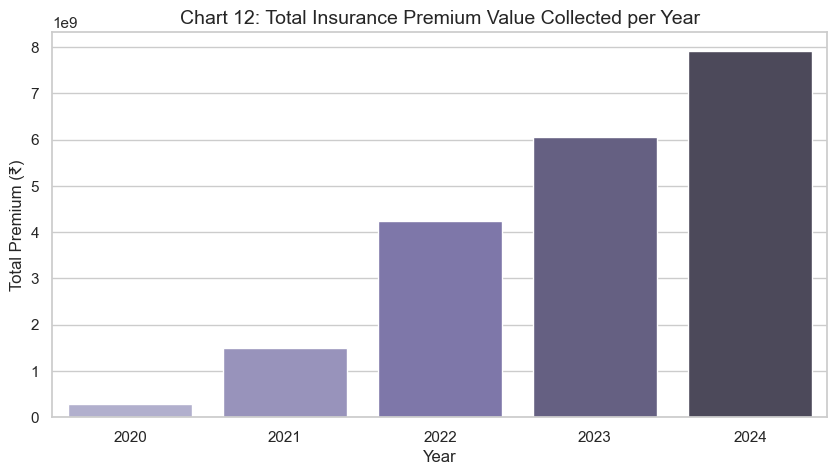

In [18]:
# CHART 12: Bivariate - Insurance Premium Value by Year (Bar Chart)
plt.figure(figsize=(10, 5))
insur_growth = df_agg_insur.groupby('Year')['Insurance_amount'].sum().reset_index()
sns.barplot(data=insur_growth, x='Year', y='Insurance_amount', palette='Purples_d')
plt.title('Chart 12: Total Insurance Premium Value Collected per Year', fontsize=14)
plt.ylabel('Total Premium (₹)')
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart helps compare yearly premium collection clearly.

##### 2. What is/are the insight(s) found from the chart?

- Strong growth from 2020 to 2024.
- Significant jump after 2021.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:

    - Indicates growing adoption of insurance products.
    - High revenue potential in this segment.

- Negative:
    - Initial low adoption suggests slow early penetration.

#### Chart - 13

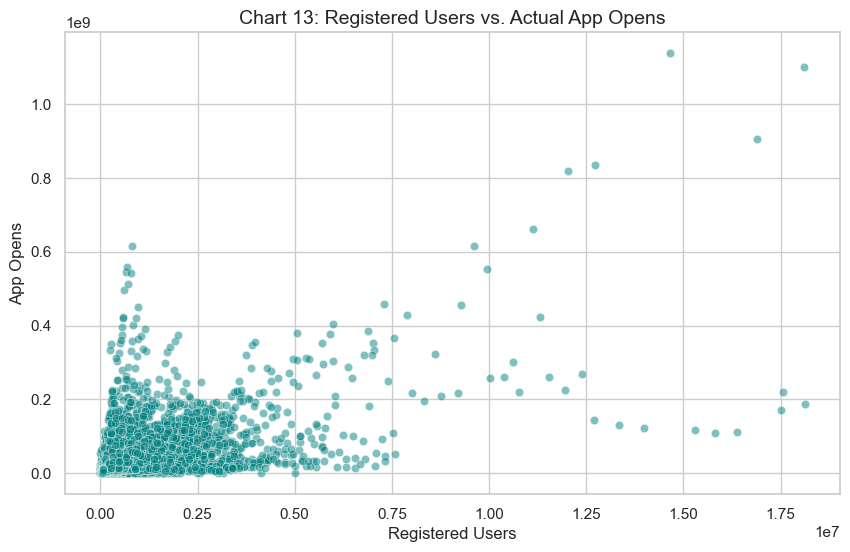

In [19]:
# CHART 13: Bivariate - Registered Users vs App Opens (Scatter)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_map_user, x='Registered_users', y='App_opens', color='teal', alpha=0.5)
plt.title('Chart 13: Registered Users vs. Actual App Opens', fontsize=14)
plt.xlabel('Registered Users')
plt.ylabel('App Opens')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot helps analyze user engagement relative to registrations.

##### 2. What is/are the insight(s) found from the chart?

- Weak to moderate relationship between users and app opens.
- Many users are registered but not highly active.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - Large user base provides potential for activation strategies.

- Negative:
    - Low engagement indicates poor retention or inactive users.

#### Chart - 14 

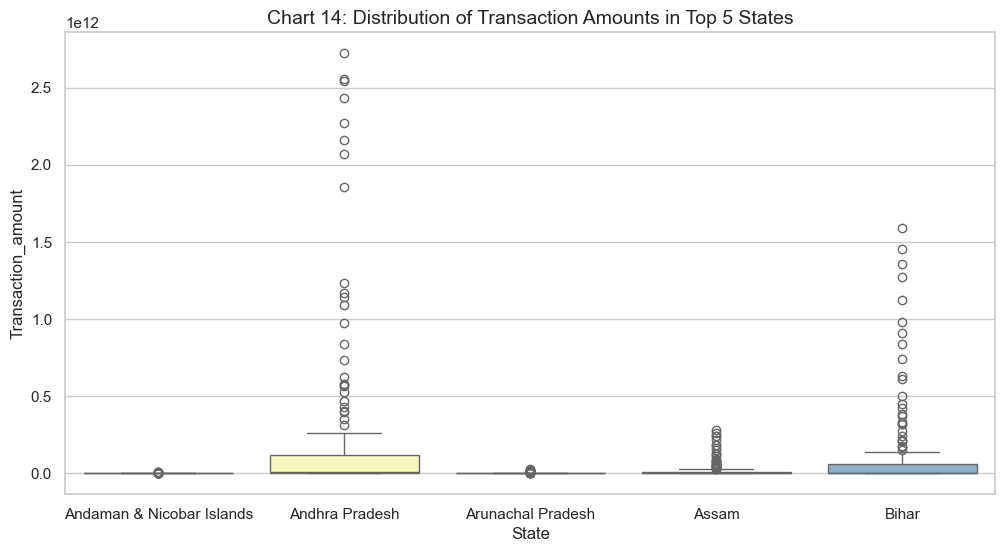

In [20]:
# CHART 14: Distribution - Transaction Amounts Boxplot
plt.figure(figsize=(12, 6))
top_5_states = df_agg_trans['State'].value_counts().head(5).index
filtered_df = df_agg_trans[df_agg_trans['State'].isin(top_5_states)]
sns.boxplot(data=filtered_df, x='State', y='Transaction_amount', palette='Set3')
plt.title('Chart 14: Distribution of Transaction Amounts in Top 5 States', fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

A box plot is useful to analyze distribution, spread, and outliers.

##### 2. What is/are the insight(s) found from the chart?

- Andhra Pradesh shows high variability and large transactions.
- Other states have smaller and more consistent transaction ranges.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - High-value transactions in some states indicate strong revenue pockets.

- Negative:
    - Uneven distribution suggests inconsistent usage patterns.

#### Chart - 15 

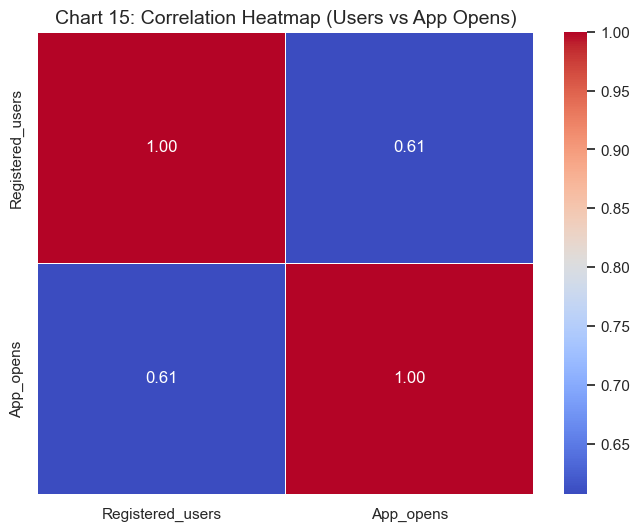

In [21]:
# CHART 15: Multivariate - Correlation Heatmap
plt.figure(figsize=(8, 6))
# Selecting only numerical columns for the heatmap
numeric_cols = df_map_user[['Registered_users', 'App_opens']]
correlation_matrix = numeric_cols.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Chart 15: Correlation Heatmap (Users vs App Opens)', fontsize=14)
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap helps quickly visualize correlation strength between variables.

##### 2. What is/are the insight(s) found from the chart?

- Moderate positive correlation (0.61) between registered users and app opens.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

- Positive:
    - More users generally lead to more app engagement.

- Negative:
    - Correlation is not strong, indicating many users are inactive or not engaging regularly.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Business Case 1: Decoding Transaction Dynamics on PhonePe**

**Scenario:** Understanding transaction behavior across different payment categories to drive targeted strategies.
- **Key Findings:** The platform's core strength lies in Peer-to-Peer (P2P) and Merchant payments. Merchant payments account for the highest transaction volume (55.4%), indicating deep integration into daily retail commerce. P2P transfers closely follow, driving the highest overall transaction value. However, high-margin categories like Financial Services and Recharge/Bill payments show minimal contribution and stagnant growth over time.
- **Actionable Recommendation:** To diversify revenue, PhonePe should leverage its massive P2P and Merchant user base to cross-sell financial services (like micro-loans or mutual funds) through targeted, in-app cashback incentives and streamlined one-click approvals.



**Business Case 2: Device Dominance and User Engagement Analysis**

**Scenario:** Analyzing user preferences across device brands to enhance app performance and marketing ROI.
- **Key Findings:** PhonePe’s user base is overwhelmingly driven by the Android ecosystem. Xiaomi leads the market share at 25.7%, followed by Samsung (19.9%) and Vivo (18.5%). Apple users constitute a very small minority (~2.8%). While overall user registration grew rapidly until 2021, there was a noticeable drop in momentum in 2022.
- **Actionable Recommendation:** Product development teams must prioritize Android optimization, particularly for mid-range devices from Xiaomi and Vivo, ensuring the app remains lightweight and fast. Marketing teams should consider co-branded campaigns or pre-installation agreements with these top smartphone manufacturers.



**Business Case 3: Insurance Penetration and Growth Potential**

**Scenario:** Analyzing the growth trajectory of PhonePe's newly launched insurance domain at the state level.
**Key Findings: The insurance segment has shown explosive, sustained growth in premium collections from 2020 through 2024. Geographically, adoption is heavily skewed toward southern and western states, with Karnataka and Maharashtra leading significantly. Northern states, such as Delhi and Rajasthan, exhibit much lower penetration rates despite having large populations.
- **Actionable Recommendation:** Capitalize on the established trust in Karnataka and Maharashtra by upselling premium, comprehensive insurance packages. For underperforming northern regions, launch localized, vernacular educational campaigns to build awareness and trust around digital insurance purchases.



**Business Case 4: Transaction Analysis for Market Expansion**

**Scenario:** Identifying top-performing and underperforming geographical areas to optimize expansion efforts.
- **Key Findings:** There is a stark digital divide in transaction volumes. Tier-1 urban districts—specifically Bengaluru Urban, Hyderabad, and Pune—dominate the platform's transaction value. Conversely, rural or remote districts (such as Nuiland and Tseminyu) report incredibly low transaction values, highlighting a lack of penetration or digital infrastructure in these areas.
- **Actionable Recommendation:** Maintain dominance in Tier-1 cities by introducing premium features and priority customer support. To capture the untapped rural market, consider launching a "lite" version of the app that works better on slower networks, or initiate agent-led onboarding programs in low-performing districts.



**Business Case 5: User Registration vs. Actual Engagement****
**Scenario:** Evaluating whether registered users are actively opening and engaging with the application.

- **Key Findings:** Data reveals a weak-to-moderate correlation (0.61) between total registered users and actual app opens. This discrepancy indicates that while acquisition strategies have successfully brought users to the platform, a significant portion of the user base remains dormant or engages very infrequently.
- **Actionable Recommendation:** Shift focus from purely user acquisition to user retention and activation. Implement targeted re-engagement strategies, such as personalized push notifications, gamified rewards for consecutive daily app opens, and inactive-user discount codes to boost Daily Active Users (DAU).

# **Conclusion**

The PhonePe Transaction Insights project successfully built a robust ETL pipeline to extract, transform, and visualize massive volumes of PhonePe Pulse data through an interactive Streamlit dashboard.

Our Exploratory Data Analysis (EDA) revealed several critical market realities. While Peer-to-Peer (P2P) and Merchant payments overwhelmingly dominate transaction volumes, high-margin financial services remain significantly underutilized, presenting a major growth opportunity. Geographically, a stark digital divide exists: Tier-1 cities (like Bengaluru and Pune) and states like Maharashtra drive the vast majority of activity and insurance adoption, while rural districts lag far behind. Additionally, user engagement is heavily concentrated within the Android ecosystem, led by brands like Xiaomi, Samsung, and Vivo.

Moving forward, to maintain its competitive edge, PhonePe should leverage its massive P2P user base to cross-sell financial products, launch targeted awareness campaigns in underperforming rural areas, and prioritize Android app optimization. This data-driven approach and the scalable dashboard will ensure sustained growth and strategic market dominance.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***